# **Bioinformatics Project - Computational Drug Discovery [Part 2] Exploratory Data Analysis**

Chanin Nantasenamat

[*'Data Professor' YouTube channel*](http://youtube.com/dataprofessor)

In this Jupyter notebook, we will be building a real-life **data science project** that you can include in your **data science portfolio**. Particularly, we will be building a machine learning model using the ChEMBL bioactivity data.

In **Part 2**, we will be performing Descriptor Calculation and Exploratory Data Analysis.

---

In [90]:
%%bash
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


## **Install conda and rdkit**

In [91]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
! chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
! bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
! conda install -c rdkit rdkit -y
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')

wget: /usr/local/lib/libuuid.so.1: no version information available (required by wget)
--2022-02-01 10:48:44--  https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.131.3, 104.16.130.3, 2606:4700::6810:8203, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.131.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85055499 (81M) [application/x-sh]
Saving to: ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh.3’

Miniconda3-py37_4.8 100%[===================>]  81,12M  58,4MB/s    in 1,4s    

2022-02-01 10:48:45 (58,4 MB/s) - ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh.3’ saved [85055499/85055499]

PREFIX=/usr/local
./Miniconda3-py37_4.8.2-Linux-x86_64.sh: line 392: /usr/local/conda.exe: Permission denied
chmod: cannot access '/usr/local/conda.exe': No such file or directory
Unpacking payload ...
./Miniconda3-py37_4.8.2-Linux-x86_64.sh: line 404: /usr/local/conda.exe: No such file or directo

In [1]:
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')

## **Load bioactivity data**

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('bioactivity_preprocessed_data.csv')

In [4]:
df

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value
0,CHEMBL102010,O=C(NCc1ccc(Cl)cc1)Nc1cccc2cnccc12,active,6.0
1,CHEMBL104623,CCC(C)(C)c1ccc(CCC(=O)Nc2cccc3cnccc23)cc1,active,13.0
2,CHEMBL103590,O=C(NCCc1ccc(Cl)c(Cl)c1)Nc1cccc2cnccc12,active,10.0
3,CHEMBL102486,O=C(NCc1ccc(Cl)c(C(F)(F)F)c1)Nc1cccc2cnccc12,active,6.0
4,CHEMBL320906,O=C(Nc1cc(C(F)(F)F)cc(C(F)(F)F)c1)Nc1cccc2cnccc12,active,32.0
...,...,...,...,...
2570,CHEMBL4543647,COc1cc2c(cc1OC)[C@H](c1ccccc1)N(C(=O)N1CCc3cc(...,inactive,53000.0
2571,CHEMBL4588287,COc1cc2c(cc1OC)[C@H](c1ccc(Cl)cc1)N(C(=O)N1CCc...,intermediate,49700.0
2572,CHEMBL4576619,COc1cc2c(cc1OC)[C@H](c1ccc(F)cc1)N(C(=O)N1CCc3...,inactive,68500.0
2573,CHEMBL4647981,CCCCCCC(C)(C)c1cc(OC)cc(OCCCCCCCC(=O)NC2CC2)c1,active,800.0


## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10 

### **Import libraries**

In [5]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [6]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem) 
        moldata.append(mol)
       
    baseData= np.arange(1,1)
    i=0  
    for mol in moldata:        
       
        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
           
        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])   
    
        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1      
    
    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]   
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)
    
    return descriptors

In [7]:
df_lipinski = lipinski(df.canonical_smiles)

### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [8]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,311.772,4.2099,2.0,2.0
1,346.474,5.4937,1.0,2.0
2,360.244,4.9058,2.0,2.0
3,379.769,5.2287,2.0,2.0
4,399.294,5.9164,2.0,2.0
...,...,...,...,...
2570,564.682,6.4362,0.0,5.0
2571,633.572,7.7430,0.0,5.0
2572,600.662,6.7144,0.0,5.0
2573,431.661,6.9412,1.0,3.0


In [9]:
df

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value
0,CHEMBL102010,O=C(NCc1ccc(Cl)cc1)Nc1cccc2cnccc12,active,6.0
1,CHEMBL104623,CCC(C)(C)c1ccc(CCC(=O)Nc2cccc3cnccc23)cc1,active,13.0
2,CHEMBL103590,O=C(NCCc1ccc(Cl)c(Cl)c1)Nc1cccc2cnccc12,active,10.0
3,CHEMBL102486,O=C(NCc1ccc(Cl)c(C(F)(F)F)c1)Nc1cccc2cnccc12,active,6.0
4,CHEMBL320906,O=C(Nc1cc(C(F)(F)F)cc(C(F)(F)F)c1)Nc1cccc2cnccc12,active,32.0
...,...,...,...,...
2570,CHEMBL4543647,COc1cc2c(cc1OC)[C@H](c1ccccc1)N(C(=O)N1CCc3cc(...,inactive,53000.0
2571,CHEMBL4588287,COc1cc2c(cc1OC)[C@H](c1ccc(Cl)cc1)N(C(=O)N1CCc...,intermediate,49700.0
2572,CHEMBL4576619,COc1cc2c(cc1OC)[C@H](c1ccc(F)cc1)N(C(=O)N1CCc3...,inactive,68500.0
2573,CHEMBL4647981,CCCCCCC(C)(C)c1cc(OC)cc(OCCCCCCCC(=O)NC2CC2)c1,active,800.0


Now, let's combine the 2 DataFrame

In [10]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [11]:
df_combined

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL102010,O=C(NCc1ccc(Cl)cc1)Nc1cccc2cnccc12,active,6.0,311.772,4.2099,2.0,2.0
1,CHEMBL104623,CCC(C)(C)c1ccc(CCC(=O)Nc2cccc3cnccc23)cc1,active,13.0,346.474,5.4937,1.0,2.0
2,CHEMBL103590,O=C(NCCc1ccc(Cl)c(Cl)c1)Nc1cccc2cnccc12,active,10.0,360.244,4.9058,2.0,2.0
3,CHEMBL102486,O=C(NCc1ccc(Cl)c(C(F)(F)F)c1)Nc1cccc2cnccc12,active,6.0,379.769,5.2287,2.0,2.0
4,CHEMBL320906,O=C(Nc1cc(C(F)(F)F)cc(C(F)(F)F)c1)Nc1cccc2cnccc12,active,32.0,399.294,5.9164,2.0,2.0
...,...,...,...,...,...,...,...,...
2570,CHEMBL4543647,COc1cc2c(cc1OC)[C@H](c1ccccc1)N(C(=O)N1CCc3cc(...,inactive,53000.0,564.682,6.4362,0.0,5.0
2571,CHEMBL4588287,COc1cc2c(cc1OC)[C@H](c1ccc(Cl)cc1)N(C(=O)N1CCc...,intermediate,49700.0,633.572,7.7430,0.0,5.0
2572,CHEMBL4576619,COc1cc2c(cc1OC)[C@H](c1ccc(F)cc1)N(C(=O)N1CCc3...,inactive,68500.0,600.662,6.7144,0.0,5.0
2573,CHEMBL4647981,CCCCCCC(C)(C)c1cc(OC)cc(OCCCCCCCC(=O)NC2CC2)c1,active,800.0,431.661,6.9412,1.0,3.0


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [12]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    #x = input.drop('standard_value_norm', 1)
    x = input
        
    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [13]:
df_combined.standard_value.describe()

count      2575.000000
mean       4488.984588
std       15247.661405
min           0.158500
25%          40.500000
50%         192.200005
75%        1800.000000
max      203000.000000
Name: standard_value, dtype: float64

In [14]:
-np.log10( (10**-9)* 100000000 )

1.0

In [15]:
-np.log10( (10**-9)* 10000000000 )

-1.0

In [16]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    #x = input.drop('standard_value', 1)
    x = input    
    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [17]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL102010,O=C(NCc1ccc(Cl)cc1)Nc1cccc2cnccc12,active,6.0,311.772,4.2099,2.0,2.0,6.0
1,CHEMBL104623,CCC(C)(C)c1ccc(CCC(=O)Nc2cccc3cnccc23)cc1,active,13.0,346.474,5.4937,1.0,2.0,13.0
2,CHEMBL103590,O=C(NCCc1ccc(Cl)c(Cl)c1)Nc1cccc2cnccc12,active,10.0,360.244,4.9058,2.0,2.0,10.0
3,CHEMBL102486,O=C(NCc1ccc(Cl)c(C(F)(F)F)c1)Nc1cccc2cnccc12,active,6.0,379.769,5.2287,2.0,2.0,6.0
4,CHEMBL320906,O=C(Nc1cc(C(F)(F)F)cc(C(F)(F)F)c1)Nc1cccc2cnccc12,active,32.0,399.294,5.9164,2.0,2.0,32.0
...,...,...,...,...,...,...,...,...,...
2570,CHEMBL4543647,COc1cc2c(cc1OC)[C@H](c1ccccc1)N(C(=O)N1CCc3cc(...,inactive,53000.0,564.682,6.4362,0.0,5.0,53000.0
2571,CHEMBL4588287,COc1cc2c(cc1OC)[C@H](c1ccc(Cl)cc1)N(C(=O)N1CCc...,intermediate,49700.0,633.572,7.7430,0.0,5.0,49700.0
2572,CHEMBL4576619,COc1cc2c(cc1OC)[C@H](c1ccc(F)cc1)N(C(=O)N1CCc3...,inactive,68500.0,600.662,6.7144,0.0,5.0,68500.0
2573,CHEMBL4647981,CCCCCCC(C)(C)c1cc(OC)cc(OCCCCCCCC(=O)NC2CC2)c1,active,800.0,431.661,6.9412,1.0,3.0,800.0


In [18]:
df_norm.standard_value_norm.describe()

count      2575.000000
mean       4488.984588
std       15247.661405
min           0.158500
25%          40.500000
50%         192.200005
75%        1800.000000
max      203000.000000
Name: standard_value_norm, dtype: float64

In [19]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm,pIC50
0,CHEMBL102010,O=C(NCc1ccc(Cl)cc1)Nc1cccc2cnccc12,active,6.0,311.772,4.2099,2.0,2.0,6.0,8.221849
1,CHEMBL104623,CCC(C)(C)c1ccc(CCC(=O)Nc2cccc3cnccc23)cc1,active,13.0,346.474,5.4937,1.0,2.0,13.0,7.886057
2,CHEMBL103590,O=C(NCCc1ccc(Cl)c(Cl)c1)Nc1cccc2cnccc12,active,10.0,360.244,4.9058,2.0,2.0,10.0,8.000000
3,CHEMBL102486,O=C(NCc1ccc(Cl)c(C(F)(F)F)c1)Nc1cccc2cnccc12,active,6.0,379.769,5.2287,2.0,2.0,6.0,8.221849
4,CHEMBL320906,O=C(Nc1cc(C(F)(F)F)cc(C(F)(F)F)c1)Nc1cccc2cnccc12,active,32.0,399.294,5.9164,2.0,2.0,32.0,7.494850
...,...,...,...,...,...,...,...,...,...,...
2570,CHEMBL4543647,COc1cc2c(cc1OC)[C@H](c1ccccc1)N(C(=O)N1CCc3cc(...,inactive,53000.0,564.682,6.4362,0.0,5.0,53000.0,4.275724
2571,CHEMBL4588287,COc1cc2c(cc1OC)[C@H](c1ccc(Cl)cc1)N(C(=O)N1CCc...,intermediate,49700.0,633.572,7.7430,0.0,5.0,49700.0,4.303644
2572,CHEMBL4576619,COc1cc2c(cc1OC)[C@H](c1ccc(F)cc1)N(C(=O)N1CCc3...,inactive,68500.0,600.662,6.7144,0.0,5.0,68500.0,4.164309
2573,CHEMBL4647981,CCCCCCC(C)(C)c1cc(OC)cc(OCCCCCCCC(=O)NC2CC2)c1,active,800.0,431.661,6.9412,1.0,3.0,800.0,6.096910


In [20]:
df_final.pIC50.describe()

count    2575.000000
mean        6.573153
std         1.112911
min         3.692504
25%         5.744727
50%         6.716247
75%         7.392545
max         9.799971
Name: pIC50, dtype: float64

# Histogram


(array([ 55.,  98., 392., 308., 470., 573., 428., 203.,  37.,  11.]),
 array([3.69250396, 4.30325064, 4.91399732, 5.52474399, 6.13549067,
        6.74623735, 7.35698402, 7.9677307 , 8.57847738, 9.18922406,
        9.79997073]),
 <BarContainer object of 10 artists>)

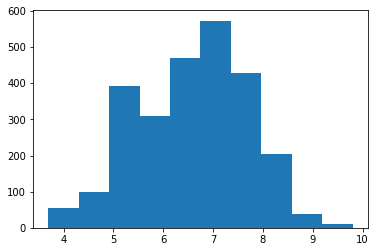

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
plt.hist(df_final['pIC50'])

In [22]:
plt.savefig("histograma.png")

<Figure size 432x288 with 0 Axes>

### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [23]:
df_2class = df_final[df_final.bioactivity_class != 'intermediate']
#df_2class

---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [24]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

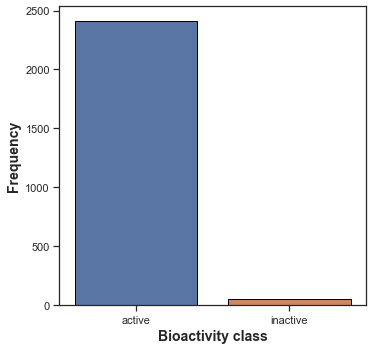

In [25]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

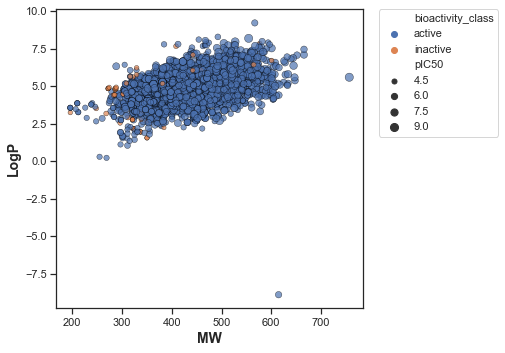

In [26]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

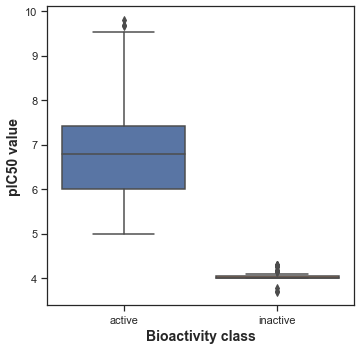

In [27]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [28]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df.bioactivity_class == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df.bioactivity_class == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'
  
  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [29]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,0.0,2.895253e-37,0.05,Different distribution (reject H0)


#### **MW**

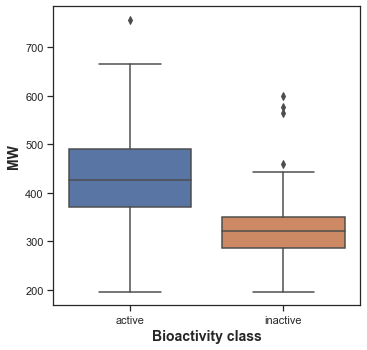

In [30]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [31]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,21201.0,2.693266e-18,0.05,Different distribution (reject H0)


#### **LogP**

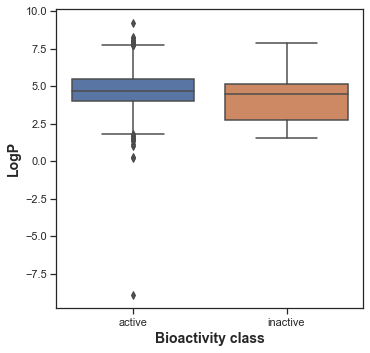

In [32]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [33]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,53929.0,0.008496,0.05,Different distribution (reject H0)


#### **NumHDonors**

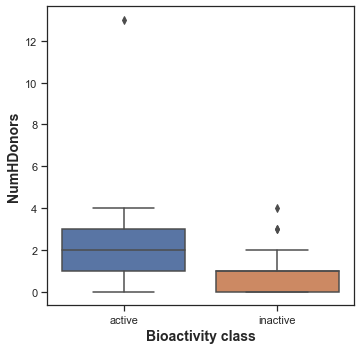

In [34]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [35]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,21097.5,3.390716e-20,0.05,Different distribution (reject H0)


#### **NumHAcceptors**

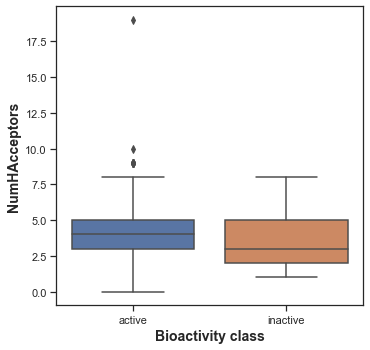

In [36]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [37]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,51347.5,0.001696,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

Of the 4 Lipinski's descriptors (MW, LogP, NumHDonors and NumHAcceptors), only LogP exhibited ***no difference*** between the **actives** and **inactives** while the other 3 descriptors (MW, NumHDonors and NumHAcceptors) shows ***statistically significant difference*** between **actives** and **inactives**.

## **Zip files**

In [38]:
! zip -r results.zip . -i *.csv *.pdf

updating: plot_NumHDonors.pdf (deflated 37%)
updating: mannwhitneyu_pIC50.csv (deflated 10%)
updating: bioactivity_data.csv (deflated 95%)
updating: bioactivity_preprocessed_data.csv (deflated 85%)
updating: ids_3+.csv (deflated 72%)
updating: ids_todos.csv (deflated 72%)
updating: plot_bioactivity_class.pdf (deflated 39%)
updating: mannwhitneyu_LogP.csv (deflated 9%)
updating: plot_ic50.pdf (deflated 37%)
updating: plot_MW_vs_LogP.pdf (deflated 3%)
updating: mannwhitneyu_MW.csv (deflated 7%)
updating: plot_LogP.pdf (deflated 38%)
updating: plot_MW.pdf (deflated 38%)
updating: mannwhitneyu_NumHDonors.csv (deflated 11%)
updating: plot_NumHAcceptors.pdf (deflated 38%)
updating: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
updating: trpv1_bioactivity_data_2class_pIC50.csv (deflated 79%)
updating: descriptors_output.csv (deflated 96%)
updating: trpv1_06_bioactivity_data_3class_pIC50_pubchem_fp.csv (deflated 96%)


export df


In [39]:
df_2class


,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm,pIC50
0,CHEMBL102010,O=C(NCc1ccc(Cl)cc1)Nc1cccc2cnccc12,active,6.0,311.772,4.2099,2.0,2.0,6.0,8.221849
1,CHEMBL104623,CCC(C)(C)c1ccc(CCC(=O)Nc2cccc3cnccc23)cc1,active,13.0,346.474,5.4937,1.0,2.0,13.0,7.886057
2,CHEMBL103590,O=C(NCCc1ccc(Cl)c(Cl)c1)Nc1cccc2cnccc12,active,10.0,360.244,4.9058,2.0,2.0,10.0,8.000000
3,CHEMBL102486,O=C(NCc1ccc(Cl)c(C(F)(F)F)c1)Nc1cccc2cnccc12,active,6.0,379.769,5.2287,2.0,2.0,6.0,8.221849
4,CHEMBL320906,O=C(Nc1cc(C(F)(F)F)cc(C(F)(F)F)c1)Nc1cccc2cnccc12,active,32.0,399.294,5.9164,2.0,2.0,32.0,7.494850
...,...,...,...,...,...,...,...,...,...,...
2569,CHEMBL4513622,C/C=C(\C)[C@H]1C(C)=C[C@H]2C[C@@H](C)C[C@@H](C...,inactive,81600.0,381.516,5.1760,1.0,3.0,81600.0,4.088310
2570,CHEMBL4543647,COc1cc2c(cc1OC)[C@H](c1ccccc1)N(C(=O)N1CCc3cc(...,inactive,53000.0,564.682,6.4362,0.0,5.0,53000.0,4.275724
2572,CHEMBL4576619,COc1cc2c(cc1OC)[C@H](c1ccc(F)cc1)N(C(=O)N1CCc3...,inactive,68500.0,600.662,6.7144,0.0,5.0,68500.0,4.164309
2573,CHEMBL4647981,CCCCCCC(C)(C)c1cc(OC)cc(OCCCCCCCC(=O)NC2CC2)c1,active,800.0,431.661,6.9412,1.0,3.0,800.0,6.096910


In [40]:
df_final.to_csv('trpv1_bioactivity_data_2class_pIC50.csv', index=False)


In [41]:
df_final

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm,pIC50
0,CHEMBL102010,O=C(NCc1ccc(Cl)cc1)Nc1cccc2cnccc12,active,6.0,311.772,4.2099,2.0,2.0,6.0,8.221849
1,CHEMBL104623,CCC(C)(C)c1ccc(CCC(=O)Nc2cccc3cnccc23)cc1,active,13.0,346.474,5.4937,1.0,2.0,13.0,7.886057
2,CHEMBL103590,O=C(NCCc1ccc(Cl)c(Cl)c1)Nc1cccc2cnccc12,active,10.0,360.244,4.9058,2.0,2.0,10.0,8.000000
3,CHEMBL102486,O=C(NCc1ccc(Cl)c(C(F)(F)F)c1)Nc1cccc2cnccc12,active,6.0,379.769,5.2287,2.0,2.0,6.0,8.221849
4,CHEMBL320906,O=C(Nc1cc(C(F)(F)F)cc(C(F)(F)F)c1)Nc1cccc2cnccc12,active,32.0,399.294,5.9164,2.0,2.0,32.0,7.494850
...,...,...,...,...,...,...,...,...,...,...
2570,CHEMBL4543647,COc1cc2c(cc1OC)[C@H](c1ccccc1)N(C(=O)N1CCc3cc(...,inactive,53000.0,564.682,6.4362,0.0,5.0,53000.0,4.275724
2571,CHEMBL4588287,COc1cc2c(cc1OC)[C@H](c1ccc(Cl)cc1)N(C(=O)N1CCc...,intermediate,49700.0,633.572,7.7430,0.0,5.0,49700.0,4.303644
2572,CHEMBL4576619,COc1cc2c(cc1OC)[C@H](c1ccc(F)cc1)N(C(=O)N1CCc3...,inactive,68500.0,600.662,6.7144,0.0,5.0,68500.0,4.164309
2573,CHEMBL4647981,CCCCCCC(C)(C)c1cc(OC)cc(OCCCCCCCC(=O)NC2CC2)c1,active,800.0,431.661,6.9412,1.0,3.0,800.0,6.096910
